# Laptop State Classification Using Computer Vision

This project classifies laptop images into two classes:

- `laptop_open`
- `laptop_closed`

The project compares a baseline Support Vector Machine (SVM) with an improved MobileNetV2 transfer learning model.

The dataset was self-collected and then augmented to increase variation.

## Dataset

Original dataset:

- 31 images of open laptops
- 31 images of closed laptops

The images were captured under different conditions:

- different angles
- different distances
- different backgrounds
- different lighting conditions
- different laptop positions

The dataset was divided into:

- 70% training
- 15% validation
- 15% testing

The training subset was augmented using rotation, brightness adjustment, contrast adjustment, horizontal flipping, blur, and crop/zoom.

In [1]:
from pathlib import Path

dataset_path = Path("../dataset")

open_images = list((dataset_path / "laptop_open").glob("*.jpg"))
closed_images = list((dataset_path / "laptop_closed").glob("*.jpg"))

print("Original laptop_open images:", len(open_images))
print("Original laptop_closed images:", len(closed_images))
print("Total original images:", len(open_images) + len(closed_images))

Original laptop_open images: 31
Original laptop_closed images: 31
Total original images: 62


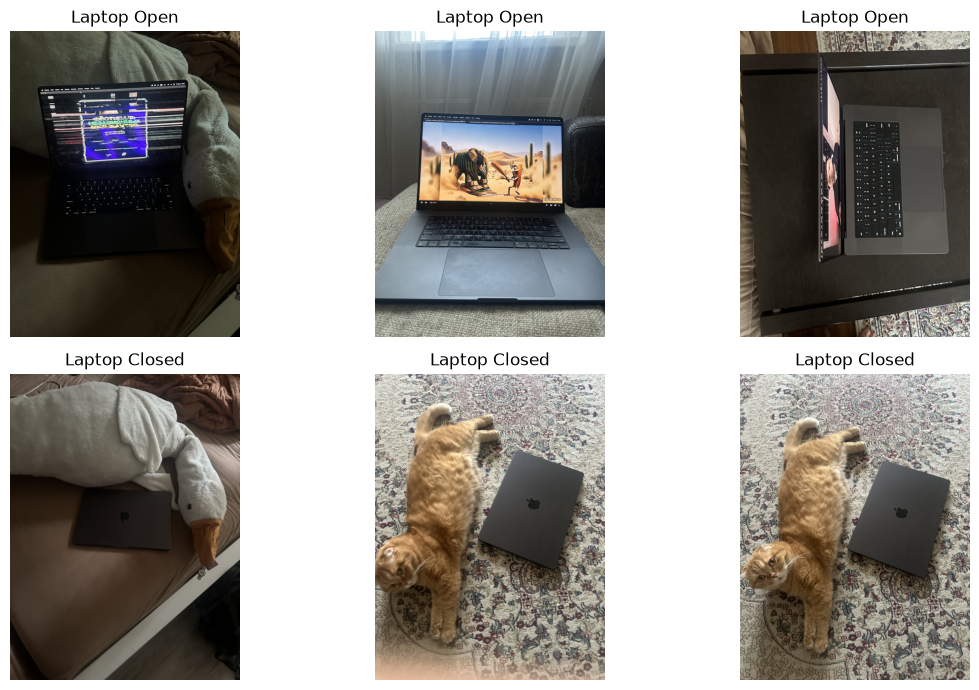

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i in range(3):
    img = Image.open(random.choice(open_images))
    axes[0, i].imshow(img)
    axes[0, i].set_title("Laptop Open")
    axes[0, i].axis("off")

for i in range(3):
    img = Image.open(random.choice(closed_images))
    axes[1, i].imshow(img)
    axes[1, i].set_title("Laptop Closed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Preprocessing and Augmentation

The original images were converted to JPG format.

For the SVM baseline:

- images were converted to grayscale
- resized to 64 × 64 pixels
- normalized to the range 0–1
- flattened into feature vectors

For MobileNetV2:

- images were resized to 224 × 224 pixels
- converted to tensors
- normalized using ImageNet normalization values

Training images were augmented to improve robustness.

In [3]:
from pathlib import Path

split_root = Path("../dataset_split")

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for class_name in ["laptop_open", "laptop_closed"]:
        files = list((split_root / split / class_name).glob("*.jpg"))
        print(class_name, len(files))


TRAIN
laptop_open 21
laptop_closed 21

VAL
laptop_open 4
laptop_closed 4

TEST
laptop_open 6
laptop_closed 6


## Baseline Model — Support Vector Machine

The baseline model was an SVM with an RBF kernel.

The SVM used grayscale 64 × 64 images represented as flattened feature vectors.

This model was used as a simple baseline for comparison with the deep learning model.

In [4]:
svm_results = {
    "Accuracy": 0.6667,
    "Precision": 0.7500,
    "Recall": 0.5000,
    "F1-score": 0.6000
}

for metric, value in svm_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.6667
Precision: 0.7500
Recall: 0.5000
F1-score: 0.6000


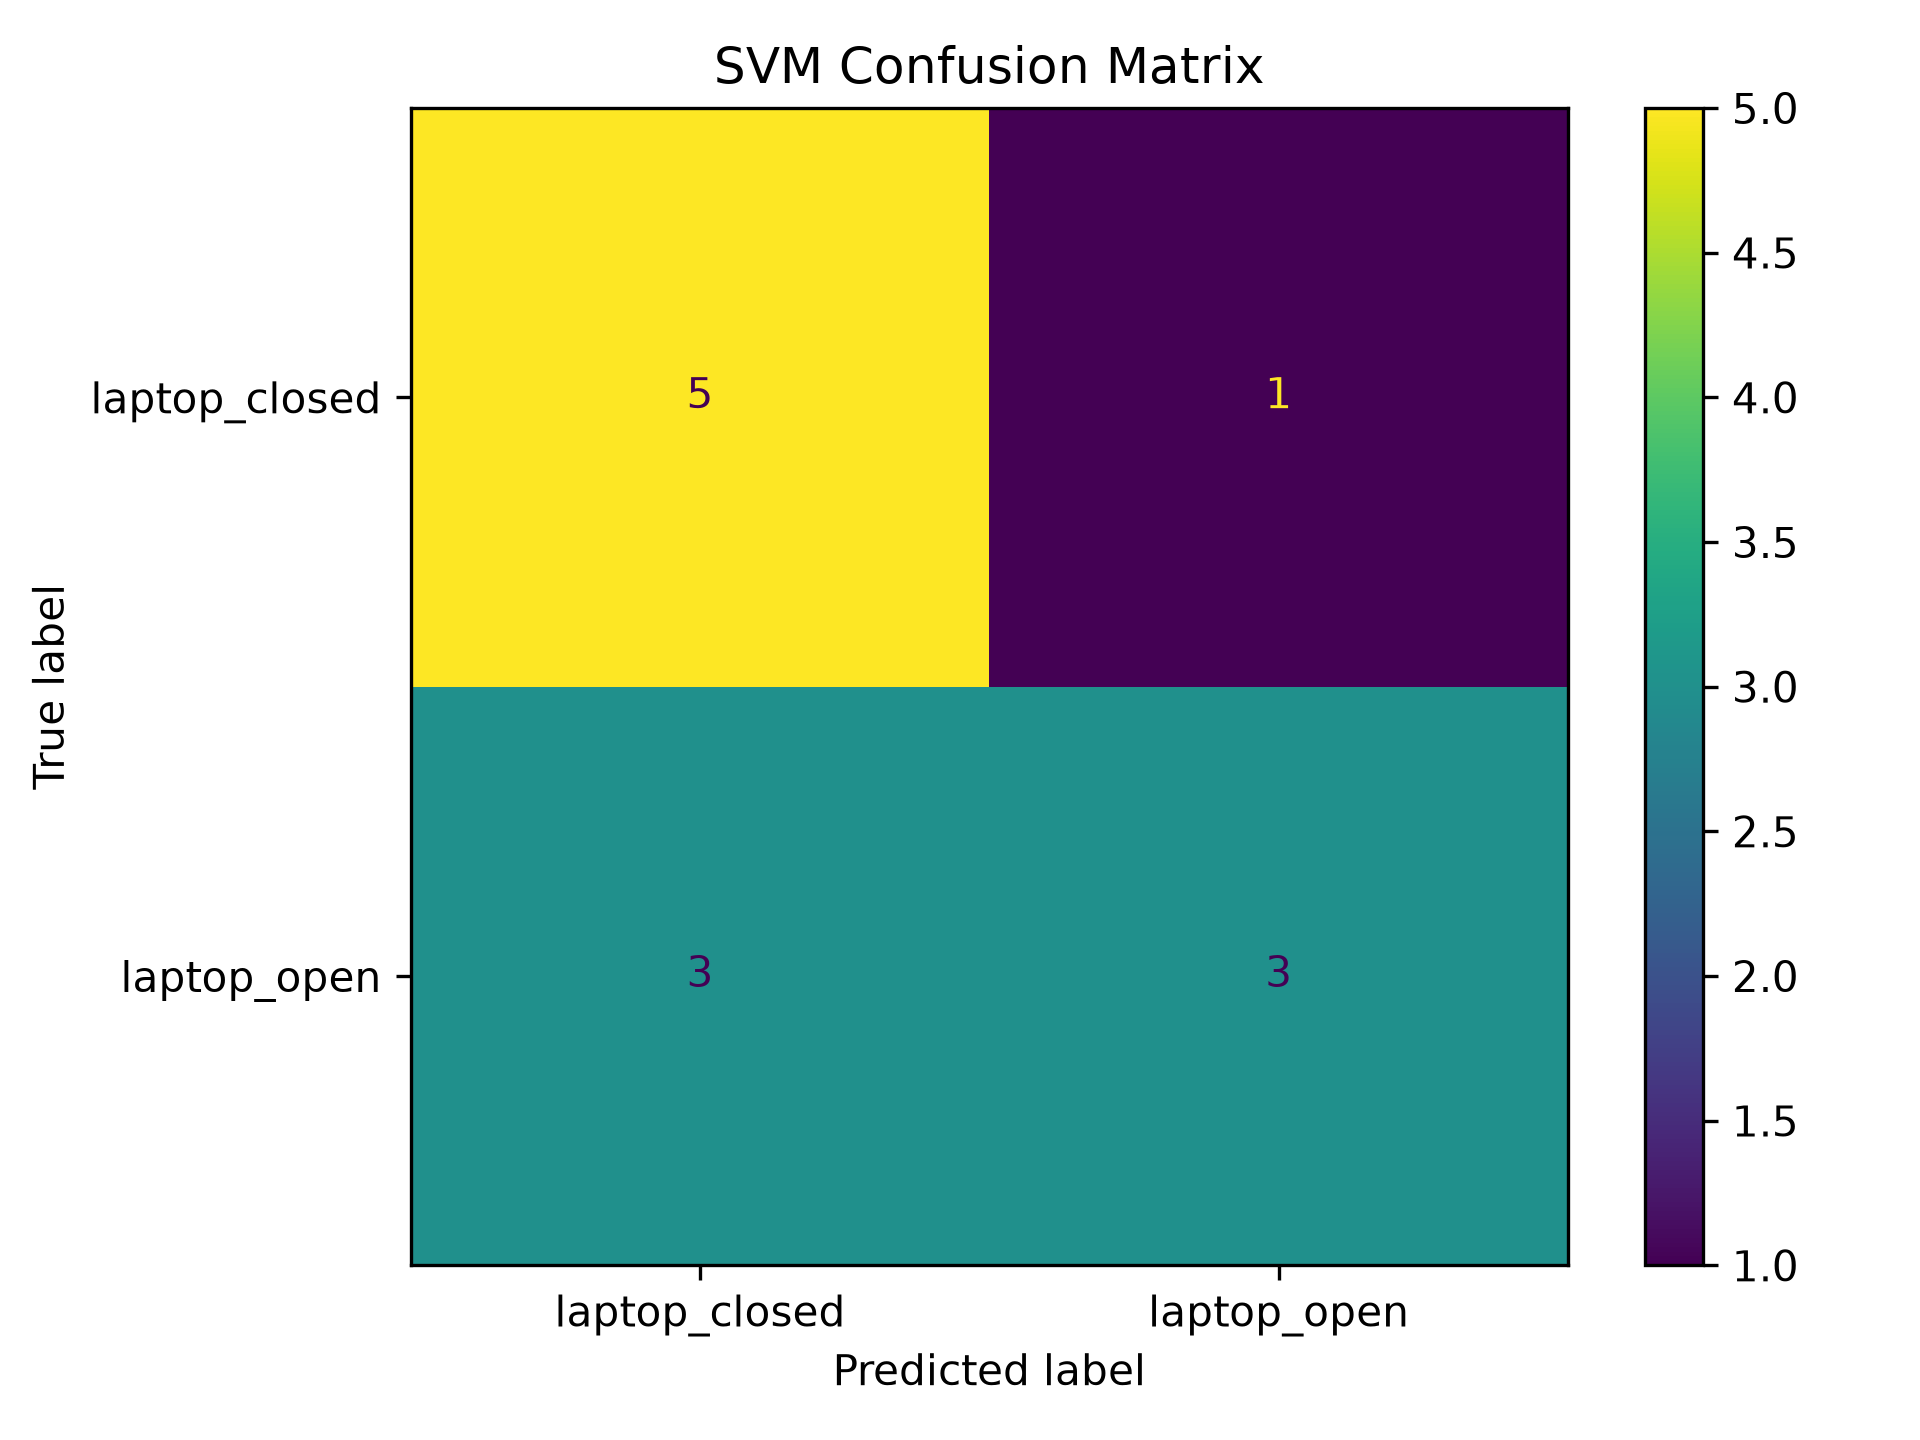

In [5]:
from IPython.display import Image, display

display(Image(filename="../results/svm_confusion_matrix.png"))

### SVM Result Analysis

The SVM achieved a test accuracy of 66.67%.

The model correctly classified most closed-laptop images but had more difficulty recognizing open laptops.

This suggests that raw grayscale pixel features are limited for this task.

## Improved Model — MobileNetV2 Transfer Learning

MobileNetV2 was used as the improved model.

The model was pretrained on ImageNet.

The convolutional feature extraction layers were frozen, while the final classification layer was replaced with a new two-class classifier.

The model was trained for 10 epochs using the Adam optimizer.

In [6]:
mobilenet_results = {
    "Accuracy": 0.9167,
    "Precision": 1.0000,
    "Recall": 0.8333,
    "F1-score": 0.9091
}

for metric, value in mobilenet_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9167
Precision: 1.0000
Recall: 0.8333
F1-score: 0.9091


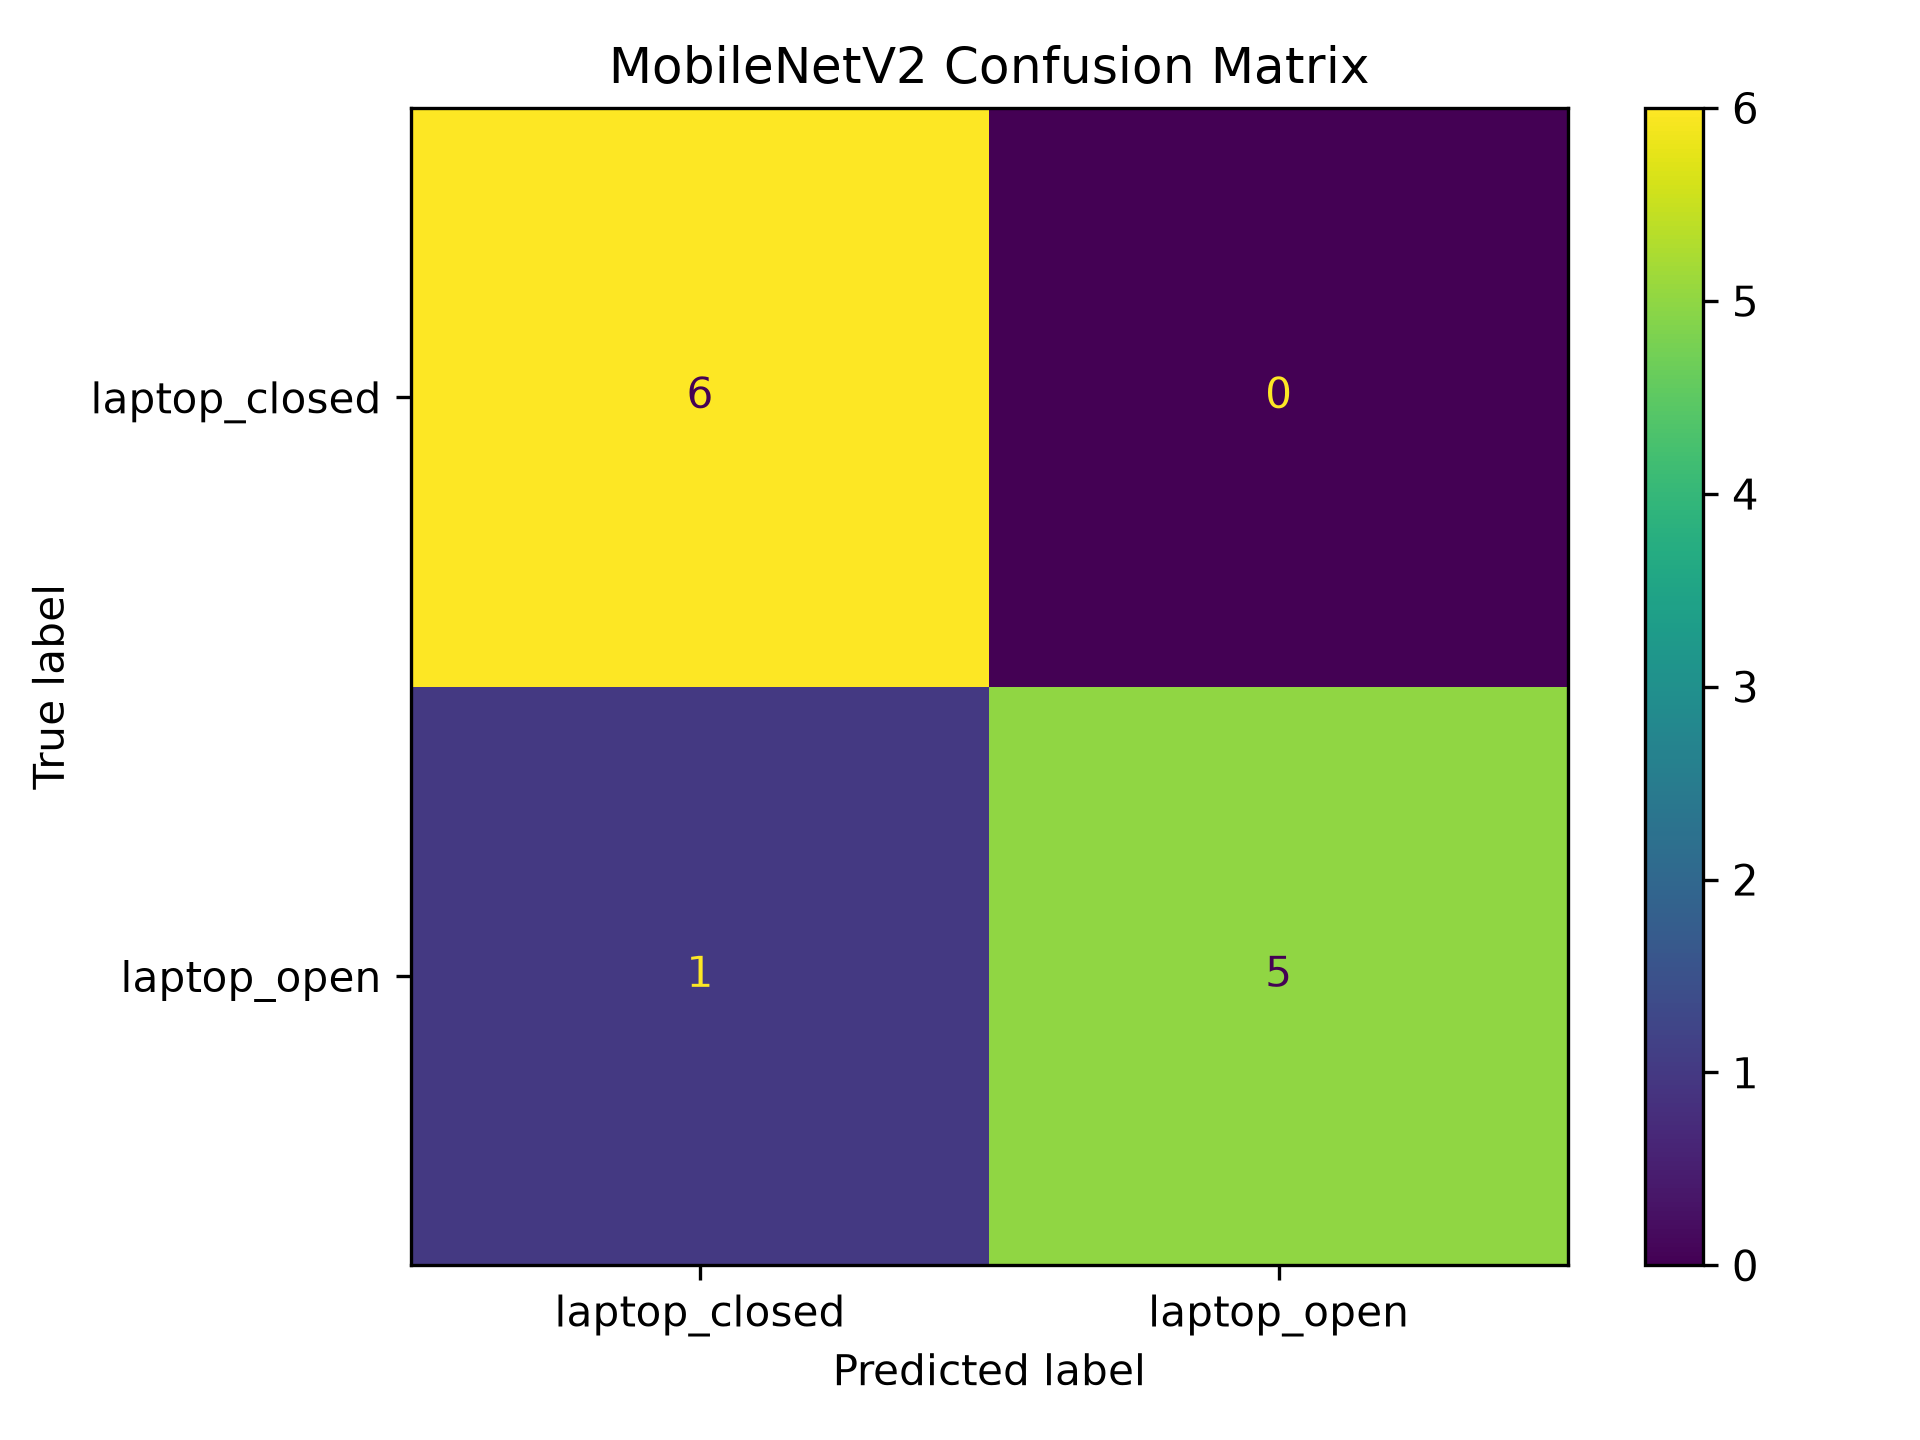

In [7]:
display(Image(filename="../results/mobilenet_confusion_matrix.png"))

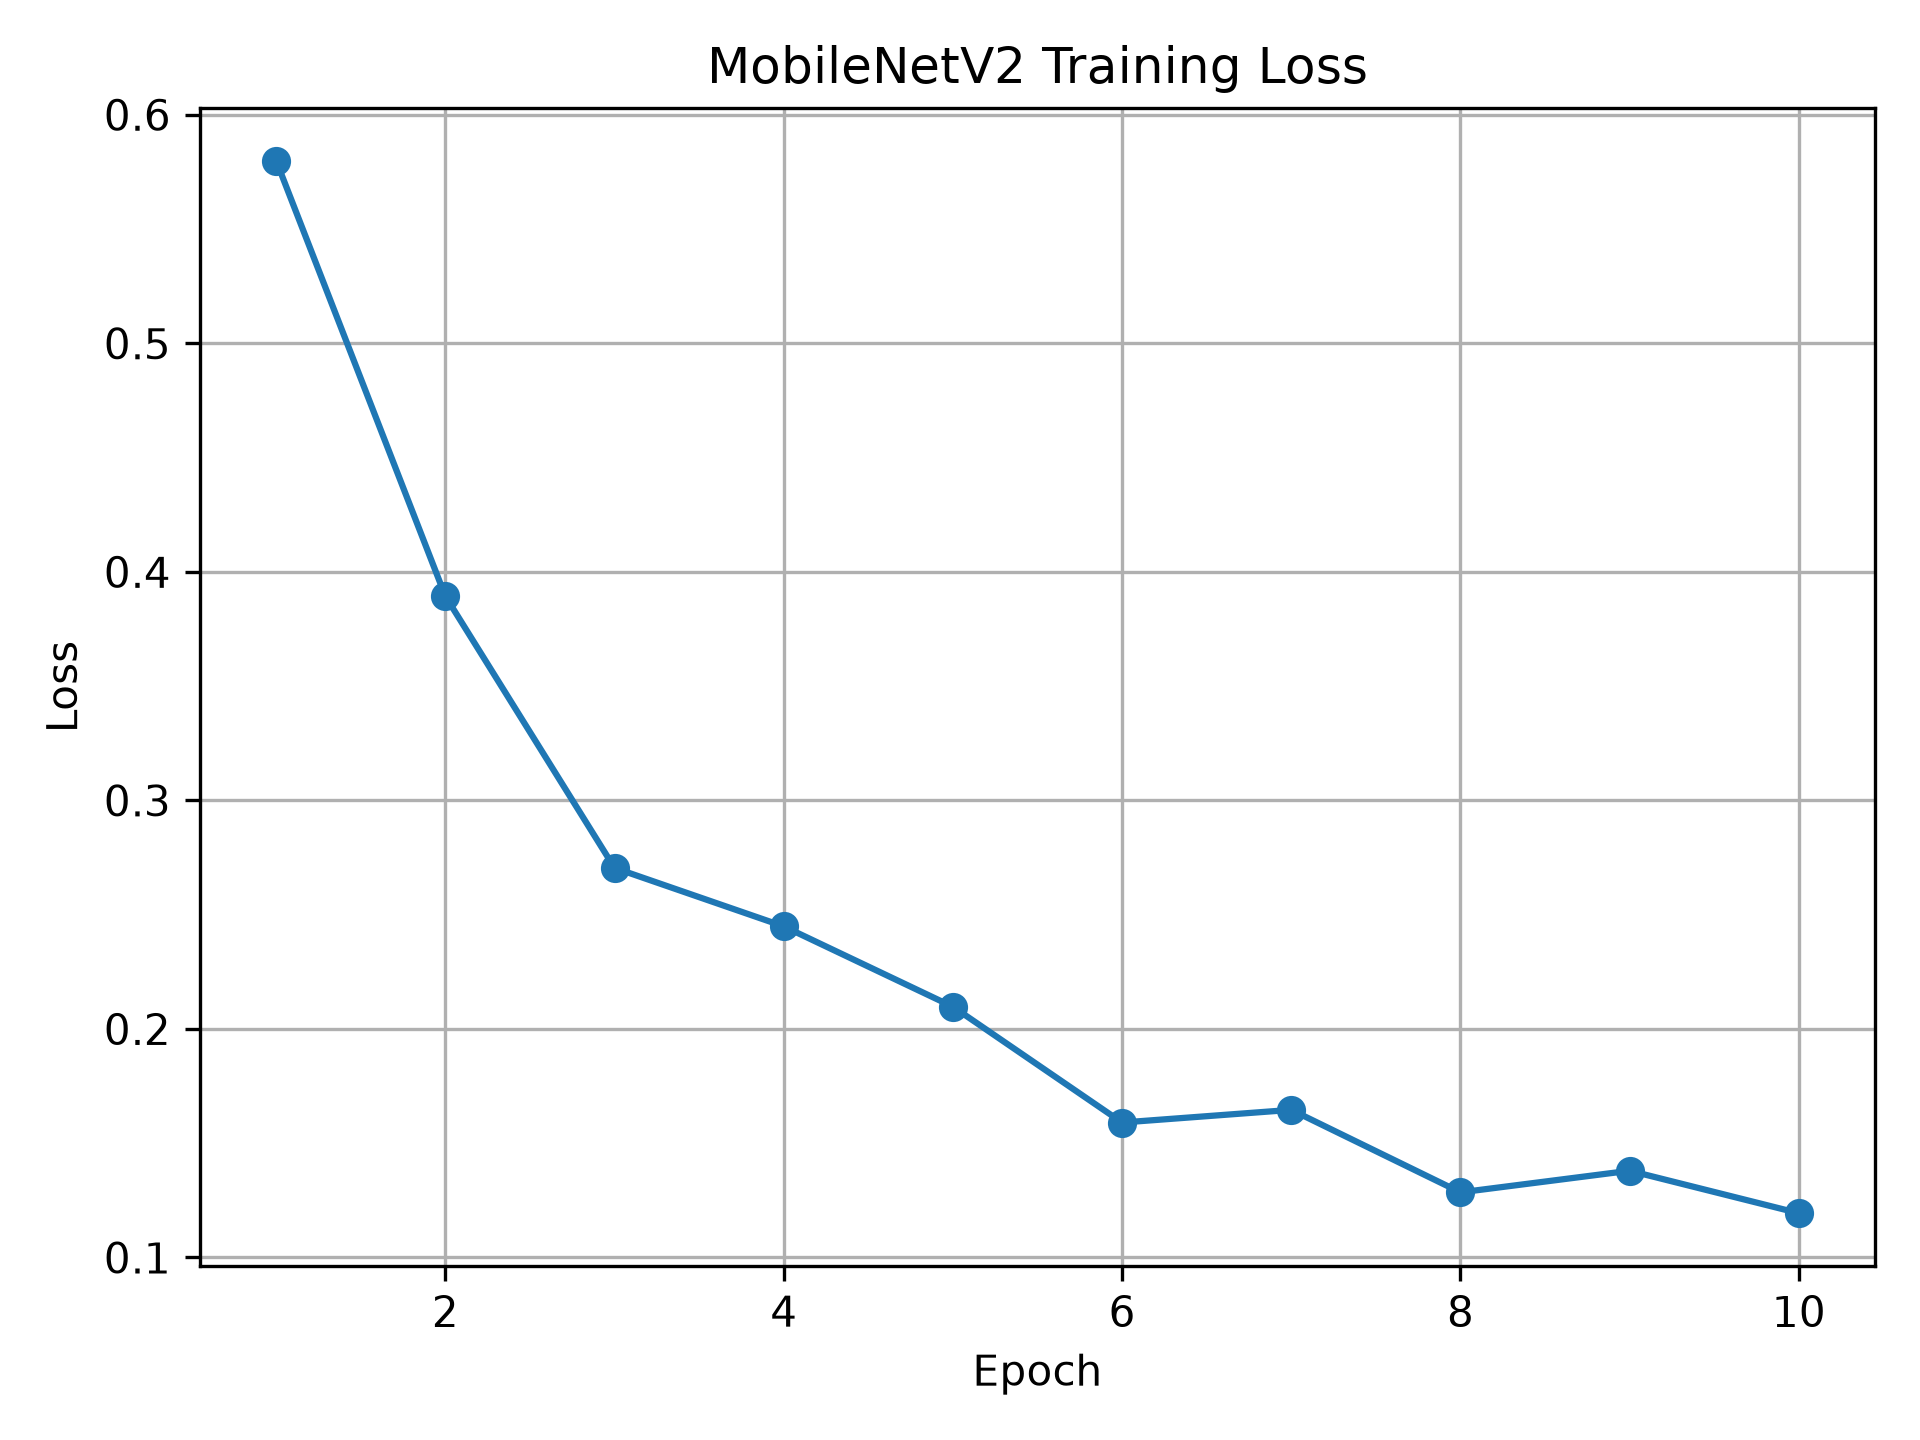

In [8]:
display(Image(filename="../results/mobilenet_training_loss.png"))

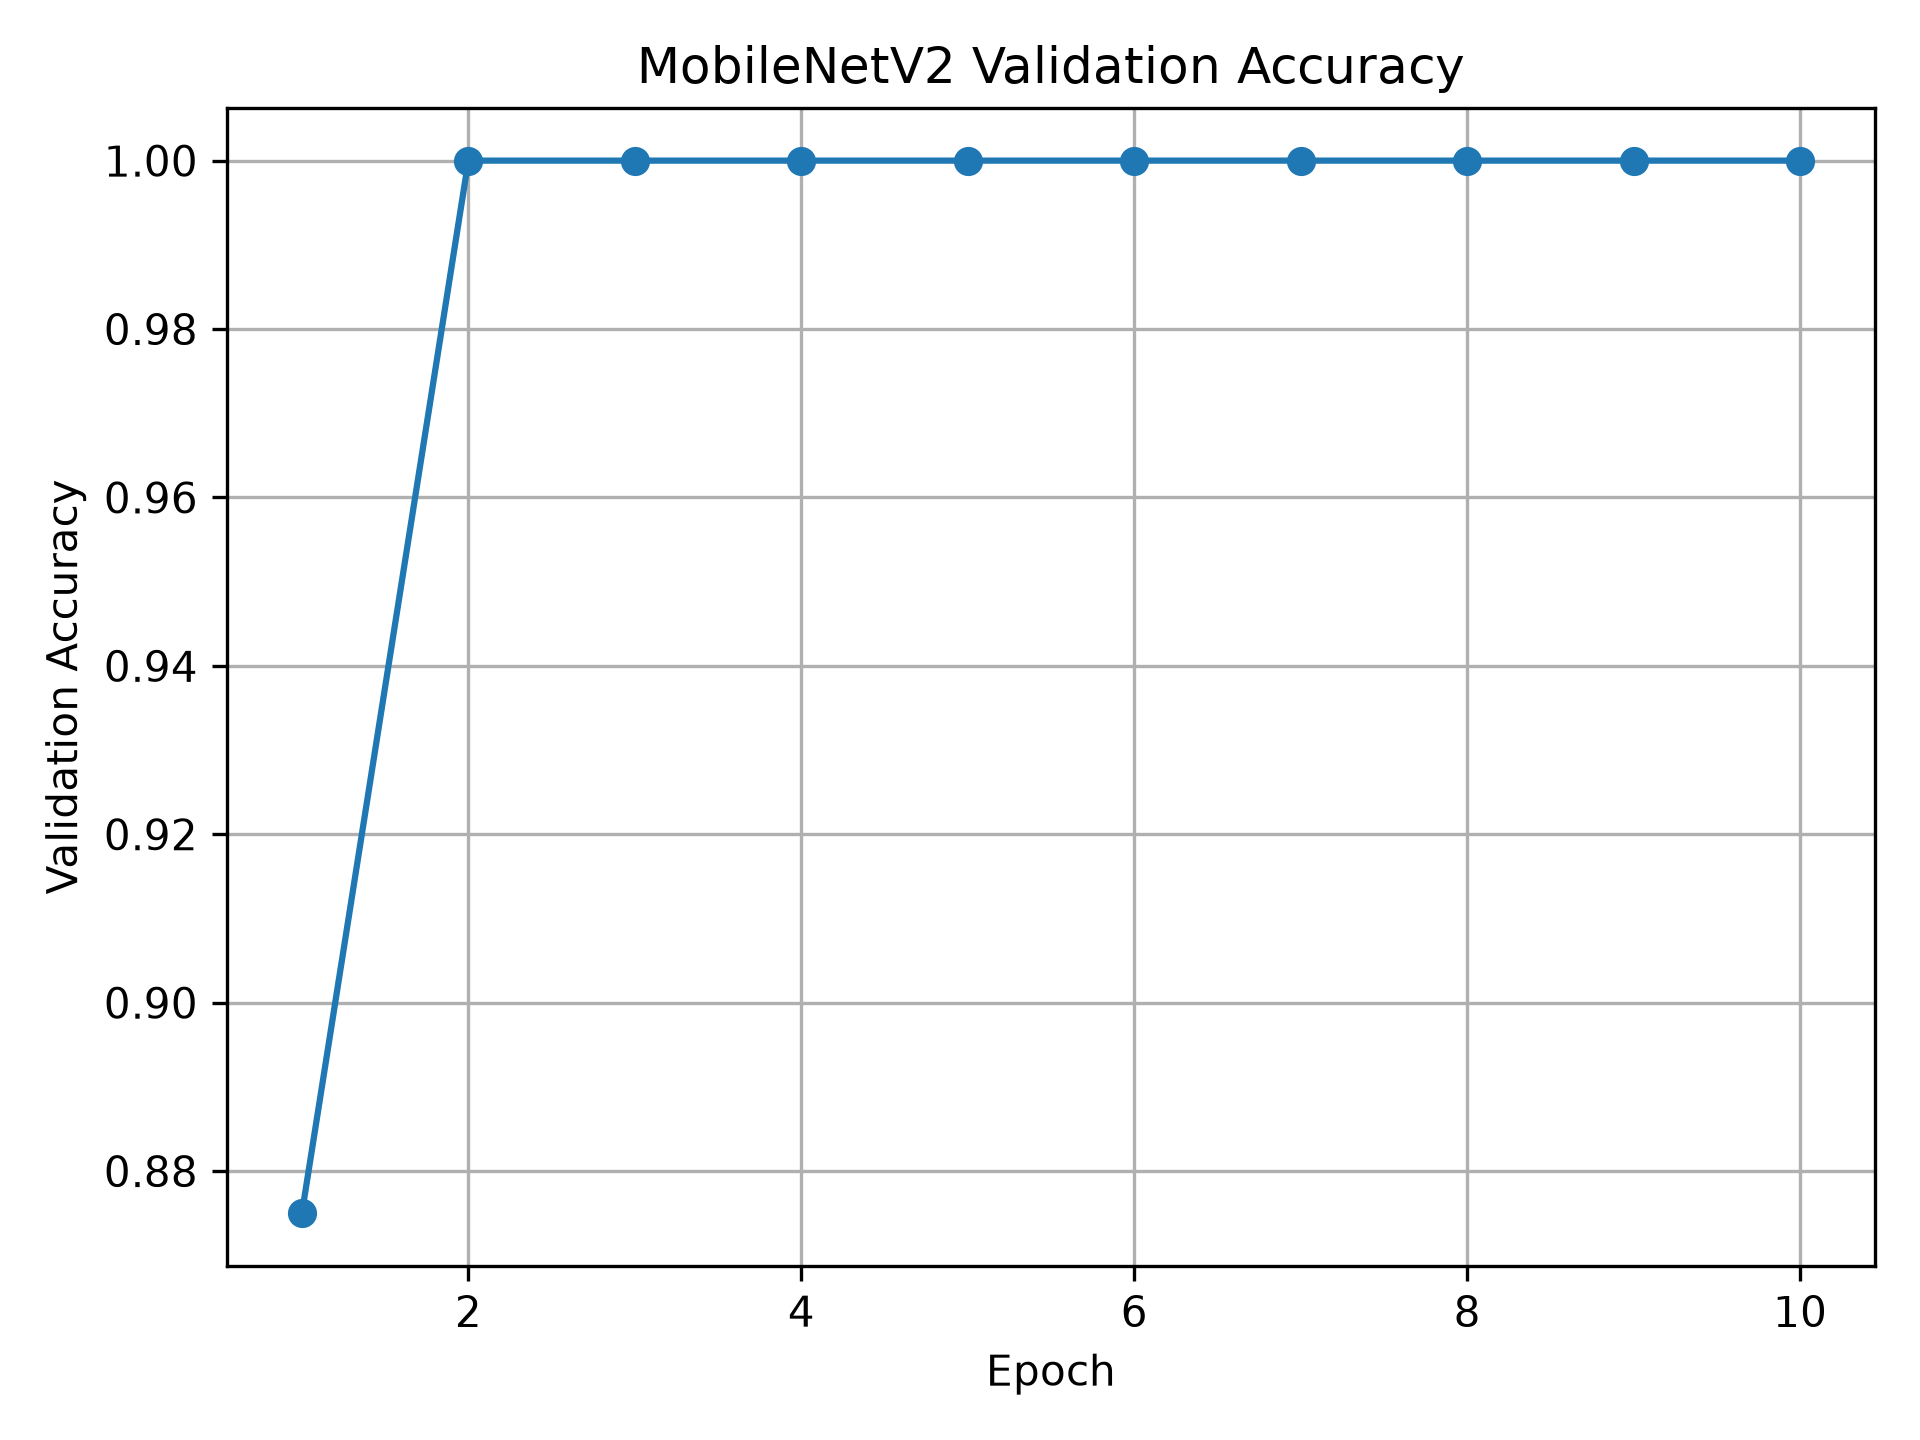

In [9]:
display(Image(filename="../results/mobilenet_validation_accuracy.png"))

### MobileNetV2 Result Analysis

MobileNetV2 achieved 91.67% test accuracy.

The model correctly classified:

- 6 out of 6 closed laptops
- 5 out of 6 open laptops

Only one test image was misclassified.

The training loss decreased consistently over the 10 epochs.

Validation accuracy reached 100%, although the validation subset was small, containing only 8 images.

In [10]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SVM", "MobileNetV2"],
    "Accuracy": [0.6667, 0.9167],
    "Precision": [0.7500, 1.0000],
    "Recall": [0.5000, 0.8333],
    "F1-score": [0.6000, 0.9091]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.6667,0.75,0.5000,0.6000
1,MobileNetV2,0.9167,1.00,0.8333,0.9091


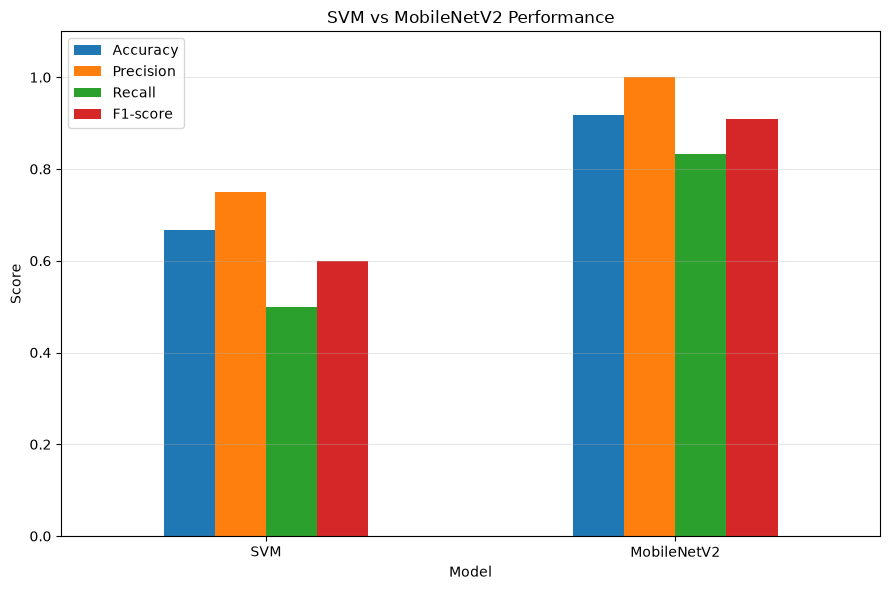

In [11]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("SVM vs MobileNetV2 Performance")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The MobileNetV2 transfer learning model significantly outperformed the SVM baseline.

SVM Test Accuracy: 66.67%

MobileNetV2 Test Accuracy: 91.67%

The improvement is likely due to the pretrained convolutional features learned by MobileNetV2.

These features can represent shapes, edges, textures, and object structure more effectively than flattened grayscale pixels.

The main limitation of the project is the relatively small original dataset.

Future work could include:

- collecting more original images
- using different laptop models
- testing under more varied lighting conditions
- increasing the test dataset size
- fine-tuning additional MobileNetV2 layers

## Conclusion

This project successfully developed a computer vision system for classifying laptop states as open or closed.

Two models were compared:

- Support Vector Machine
- MobileNetV2 Transfer Learning

MobileNetV2 achieved the best performance with 91.67% test accuracy and an F1-score of 90.91%.

The results demonstrate that transfer learning is more effective than a traditional SVM baseline for this image classification task.